---
title: "Conditioning & stability"
subtitle: "Lecture 3: Conditioning and stability and the start of Chapter 2: Solving nonlinear equations in 1d"
code-fold: true
format:
  html: default
  pdf: default
---

{{< include ../extras/_lecture-header.html >}}

::: {.callout-note}

This lecture is based on Chapter 1 of [Fundamentals of Numerical Computation by Driscoll, Braun] which is avaliable <a href="https://fncbook.com/overview/" 
     class="btn btn-outline-info btn-sm" 
     target="_blank" 
     rel="noopener noreferrer">
    <i class="bi bi-archive me-1" aria-hidden="true"></i>
    online
    <span class="visually-hidden">(opens in a new tab)</span>
  </a>

:::

## Recap 

ChimeIn: floating point numbers, round off error, ... 

::: {#exr-ep-over-2}

[](../exercises/bank.html#bank-exr-ep-over-2)

Let $\epsilon$ be the machine precision. Is $(1 + \epsilon/2) - 1 = 1 + (\epsilon/2-1)$ in Float64?

::: {.exercise-solution style="display:none;"}

In [1]:
#| code-fold: false 

ϵ = eps( Float64 )
(1.0 + ϵ/2) - 1.0 == 1.0 + (ϵ/2 - 1.0)

false

This is false, since $1 + \epsilon$ is the smallest float larger than $1$, Julia has to round or truncate $1 + \epsilon/2$:

In [2]:
#| code-fold: false 

1 + ϵ/2

1.0

Therefore, $(1 + \epsilon/2) -1 = 0$. On the other hand $\epsilon/2 - 1$ is a float and so $1 + (\epsilon/2 - 1)$ is not equal to $0$.

:::
:::

::: {#exr-fp-sums}

[](../exercises/bank.html#bank-exr-fp-sums)

Let $X$ be an array containing $10^{16}, -10^{16}$, and $N$ copies of $1$. What is the sum of all the entries of the array $X$? Does it depend on the order of summation? What about in ``Float64``? Why?


::: {.exercise-solution style="display: none;"}

In [3]:
#| code-fold: false 

using Random

N = 10^2
X = vcat( [1e16, -1e16], fill(1., N) )

for _ ∈ 1:10 
    shuffle!(X)
    s = 0. 
    for x ∈ X
        s += x 
    end
    println(s)
end 

72.0
32.0
92.0
25.0
44.0
94.0
77.0
96.0
55.0
26.0


This happens because $2^{53} \leq 10^{16} < 2^{54}$ and so the spacing between floats in this interval is $2^{n-k} = 2^{53-52} = 2$ (in Float64, the binary precision is $k=52$). As a result $10^{16} + 1$ is not a float; Julia rounds this to $10^{16}$:

In [4]:
#| code-fold: false

1e16 + 1

1.0e16

:::

:::

::: {.callout-warning} 
# Subtractive cancellation

When adding or subtracting numbers so that the result is much smaller in magnitude. For example, we know $x = -1.0000000000000000000147$ to $23$ significant digits but $x + 1 = -1.47 \times 10^{-20}$ to only $3$ significant digits. 

:::

This concept can be illustrated using (relative) condition number: 

## Conditioning

Suppose we are interested in a quantity $f(x)$ for $x\in \mathbb R$. In practice, we can only store $\widetilde{x} := \mathrm{fl}(x)$ in a computer (recall that $\widetilde{x} = x(1 + \epsilon)$ for some $|\epsilon|\leq \frac12 \epsilon_{\mathrm{mach}}$). Then the ratio of the relative error in the output to the relative error in the input in the limit as the precision goes to zero is known as the *(relative) condition number* $\kappa_f(x)$: 


::: {#def-rel-condition-number}
# Relative condition number

\begin{align}
\kappa_f(x) := \lim_{\epsilon\to0}\left|
    \frac
        {f(x) - f(x + \epsilon x)}
        {\epsilon f(x)}
    \right| \nonumber
    %
\end{align}

:::

That is, the (relative) condition number is approximately the constant of proportionality between the relative error in the output and the relative error of the input:


\begin{align}
    \left|\frac
        {f(x) - f(\widetilde{x})}
        {f(x)} \right|
    \approx \kappa_f(x) \left|\frac
        {x - \widetilde{x}}
        {x} \right|
    %
    = \kappa_f(x) |\epsilon|. \nonumber
\end{align}

::: {#exm-cond-1}

The condition number of $f(x) = x + 1$ is $\kappa_f(x) = \left|\frac{x}{x+1}\right|$. This blows up when $x\approx -1$ which explains subtractive cancellation that we mentioned above.

:::

::: {#def-illcond}

If the condition number is large, we say the problem is *ill-conditioned* or the problem is badly conditioned 

:::

Notice that 

\begin{align}
    \kappa_f(x) &= \lim_{\epsilon\to0}\left|
    \frac
        {f(x) - f(x + \epsilon x)}
        {\epsilon f(x)}
    \right| \nonumber\\
    %
    &= \lim_{\epsilon\to0}\left|
    \frac
        {f(x) - f(x + \epsilon x)}
        {\epsilon x}
    \right|
    \left| \frac{x}{f(x)} \right| \nonumber\\
    %
    &= \left| \frac{x f'(x)}{f(x)} \right|
\end{align}

::: {.box}
**Exercise**

@exr-cond-2

:::

::: {#exm-poly-roots}
# Polynomial roots as a function of monomial basis coefficients

The polynomial 

\begin{align}
    a \xi^2 + b \xi + c = 0
\end{align}

has roots $\xi_1,\xi_2$. Fix $b,c$ and consider $\xi_1 = \xi_1(a)$. What is $\kappa_{\xi_1}(a)$?

:::

::: {.callout-warning}

For higher-order polynomials, representing functions in the standard monomial basis ($\{1, x, x^2, \dots\}$) is usually a bad idea. Monomial bases are ill-conditioned; tiny perturbations in the coefficients can drastically change the behaviour of the polynomial and shift the roots significantly. To maintain numerical stability, it's a better idea to use to an orthogonal basis like Chebyshev polynomials (see later in the semester). 

Potential presentation topics include: Wilkinson’s Polynomial, conditioning of Vandermonde matrices, understand and explain [this](https://www.chebfun.org/examples/linalg/CondNos.html), [this](https://www.chebfun.org/examples/linalg/CondVandermonde.html), ....

:::

Poor conditioning is a problem with the problem! On the other hand, if we see a large error in the result, the problem might be with the solution! That is, the algorithm can also introduce errors. When the error can not be explained by an ill-conditioned problem, we will say the algorithm is *unstable*.

## Stability: An Example {#arithmetic}

Consider $\xi^2 - (10^n + 10^{-n})\xi + 1 = 0$. The roots of this equation are $\xi_1 := 10^{-n}$ and $\xi_2 := 10^n$. These roots are well separated so we expect the problem of finding the roots to be well-conditioned. We show below that the quadratic formula is ***unstable***.  

The quadratic formula in floating point arithmetic gives:

In [5]:
n = 8;
a, b, c = 1, -(10.0^n + 10.0^(-n)), 1;
ξ1, ξ2 = ( -b - sqrt( b^2 - 4*a*c) )/(2*a), ( -b + sqrt( b^2 - 4*a*c) )/(2*a);

@show ( ξ1, ξ2 ) ;

(ξ1, ξ2) = (1.4901161193847656e-8, 1.0e8)


The error in approximating the first root is quite big!

In [6]:
println( "relative errors = (", abs( ξ1 - 10.0^(-n) )/10.0^(-n) , ", ", abs( ξ2 - 10.0^n )/10.0^n, ")" )

relative errors = (0.49011611938476557, 0.0)


But why?

In [7]:
#| code-fold: false
-b

1.0000000000000001e8

In [8]:
#| code-fold: false
sqrt( b^2 - 4 * a * c )

9.999999999999999e7

In [9]:
#| code-fold: false
-b - sqrt( b^2 - 4*a*c)

2.9802322387695312e-8

The error is coming from ***Subtractive Cancellation***! The quadratic formula is thus ill-conditioned. Alternatively we could compute $\xi_1$ from $\xi_2$:

In [10]:
#| code-fold: false
ξ1 = (c/a)/ξ2

1.0e-8

Which is exact in ``Float64``.  

Another way of computing $\xi_1$ is to ***rationalise the numerator***:

\begin{align}
    \xi_1 
    &= \frac{ -b - \sqrt{ b^2 - 4ac } }{2a} \\
    %
    &= \frac{ -b - \sqrt{ b^2 - 4ac } }{2a}
    \times \frac{ -b + \sqrt{ b^2 - 4ac } }{-b + \sqrt{ b^2 - 4ac } } \nonumber\\
    %
    &= \frac
        { b^2 - ( b^2 - 4ac ) }
        {2a( -b + \sqrt{ b^2 - 4ac } )} \\
    %
    &= \frac
        { 2c }
        { -b + \sqrt{ b^2 - 4ac } }
\end{align}

Using this formula, we get

In [11]:
#| code-fold: false
ξ1 = 2*c / ( -b + sqrt(b^2 - 4*a*c) )

1.0e-8

Which is again exact in ``Float64``

## FNC Exercises

We then looked at questions 1.4.1 and 1.4.2 from <a href="https://fncbook.com/stability/">[Fundamentals of Numerical Computation by Driscoll, Braun]</a> 

::: {#exr-FNC-1-4-1}

[](../exercises/bank.html#bank-exr-FNC-1-4-1)

Exercise 1.4.1 from @fnc, <a href="https://fncbook.com/stability/">[Fundamentals of Numerical Computation by Driscoll, Braun]</a> 

::: {.exercise-hint style="display: none;"}

In [12]:
#| code-fold: false
f = x -> (1 - cos(x) )/sin(x)
g = x -> 2*sin(x/2)^2/sin(x)

(f(1e-6), g(1e-6))

(5.000444502912538e-7, 5.000000000000416e-7)

:::

::: {.exercise-solution style="display: none;"}

Since $1 - \cos x = 2 \sin^2 \frac{x}{2}$, the formulas $f(x) = \frac{1 - \cos x}{\sin x}$ and $g(x) = \frac{2 \sin^2(x/2)}{\sin x}$ are mathematically identical (both equal $\tan \frac{x}{2}$).

In floating point, however, they are different for small $x$. For $x = 10^{-6}$ (see the code above):

* $f(10^{-6}) \approx 5.000444 \times 10^{-7}$, with relative error $\approx 9 \times 10^{-5}$ (only about $4$ correct significant digits),
* $g(10^{-6}) \approx 5.000000000000416 \times 10^{-7}$, which is correct to machine precision (relative error $\approx 10^{-16}$).

The problem itself is well-conditioned: with $F(x) = \tan\frac{x}{2}$, we have $\kappa_F(x) = \left|\frac{x F'(x)}{F(x)}\right| = \frac{x}{\sin x} \approx 1$ for small $x$. The large error in $f$ is therefore due to the *algorithm*: $\cos(10^{-6}) \approx 1 - 5 \times 10^{-13}$, so computing $1 - \cos x$ subtracts two nearly equal numbers (subtractive cancellation) and loses about $12$ significant digits. The formula $g$ involves no such subtraction, and so is stable.

:::

:::

::: {#exr-FNC-1-4-2}

[](../exercises/bank.html#bank-exr-FNC-1-4-2)

Exercise 1.4.2 from @fnc, <a href="https://fncbook.com/stability/">[Fundamentals of Numerical Computation by Driscoll, Braun]</a>


::: {.exercise-hint style="display: none;"}

In [13]:
#| code-fold: false
x = @. 10.0^(-(1:11));
f = @. (exp(x) - 1)/x;

p=1;
for n ∈ 1:8
    p = @. p + x^n/( factorial(n+1) );
end 

abs.(f-p) ./ x

11-element Vector{Float64}:
    1.1102230246251565e-14
    1.0880185641326532e-12
    4.285460875053104e-11
    4.32542890393961e-9
    9.701794922989393e-7
    3.798317216308078e-5
    0.005663214341922184
    1.1077470940534795
   82.24037095772019
  826.9037099495335
 8273.537099867668

In [14]:
# upper bound on the error between f and p as functions on x
err = @. (1/factorial(10)) * (x^9/(1-x))

11-element Vector{Float64}:
 3.061924358220656e-16
 2.7835675983824175e-25
 2.7584904128114e-34
 2.7560075231509052e-43
 2.7557594799933906e-52
 2.755734678133266e-61
 2.7557321979718108e-70
 2.755731949955909e-79
 2.755731925154322e-88
 2.7557319226741635e-97
 2.755731922426145e-106

:::

::: {.exercise-solution style="display: none;"}

Using the Taylor expansion of $e^x$, we have 

\begin{align}
    f(x) = \frac{e^x - 1}{x} = \sum_{n=0}^\infty \frac{x^n}{(n+1)!}, \qquad 
    p(x) := \sum_{n=0}^{8} \frac{x^n}{(n+1)!}. \nonumber
\end{align}

For $0 < x < 1$, the truncation error satisfies

\begin{align}
    |f(x) - p(x)| = \sum_{n = 9}^\infty \frac{x^n}{(n+1)!} \leq \frac{1}{10!} \sum_{n=9}^\infty x^n = \frac{x^9}{10!\,(1-x)}, \nonumber
\end{align}

which is less than $3.1 \times 10^{-16}$ for $x \leq 0.1$ (see the second code cell above). Since $f(x) \geq 1$, the polynomial $p$ is accurate to machine precision for all $x \in (0, 0.1]$.

On the other hand, the formula $\frac{e^x - 1}{x}$ suffers from subtractive cancellation for small $x$ ($e^x \approx 1$): its relative error grows roughly like $\epsilon_{\rm mach}/x$, from $\approx 10^{-14}$ at $x = 10^{-2}$ to $\approx 10^{-8}$ at $x = 10^{-8}$. The differences $|f - p|$ computed above are therefore almost entirely the error of the naive formula, not the truncation error of $p$. (Julia's ```expm1``` avoids this problem: ```expm1(x)/x``` is accurate for all small $x$.)

:::

:::

## Chapter 2. Solving nonlinear equations in 1d {#sec-chapter-2}

::: {.callout-note}

This chapter will be mainly based on Chapter 1 of @Suli.

:::

::: {#def-root}

We say $\xi$ is a **root** (or a **zero**) of $f: [a,b] \to \mathbb R$ if $f(\xi) = 0$. 

:::

* Simple functions can be solved explicitly e.g. $ax^2 + bx + c = 0$ (also true for degree $3,4$)  
* $x^5 - 4x - 2 = 0$ - no closed formula for roots of this equation

In [15]:
#| include: false

# IF YOU HAVE DOWNLOADED THESE NOTES, 
# LET ME KNOW AND I'LL GIVE OUT 
# CHOCOLATE IN THE NEXT LECTURE

using Polynomials  
using Plots
using LaTeXStrings

p = Polynomial(-2 - 4*x + x^5)


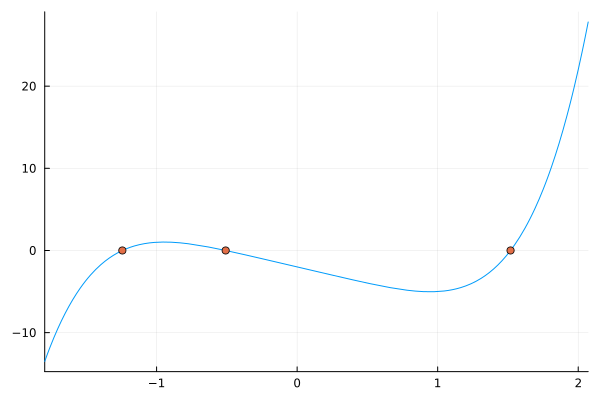

In [16]:
p = Polynomial([-2, -4, 0, 0, 0, 1]) 
@show p;

plot(p, legend=false)
plot!( real( filter( isreal, roots(p) ) ), zeros(3), seriestype=:scatter )

* Need numerical methods to get the roots!
* Aim: for $f: [a,b] \to \mathbb R$, solve $f(\xi) = 0$ for $\xi \in \mathbb R$, 
* Also, can find $\xi$ such that $f(\xi) = y$ (by considering $x \mapsto f(x) - y$) or stationary points (by considering $f = F'$),
* Simple examples with no solution, e.g. $f(x) = x^2 + 1$

::: {#thm-intermediate-value}
# Intermediate value theorem

Suppose that $f : [a,b] \to \mathbb R$ is continuous and $f(a) < y < f(b)$ or $f(b) < y < f(a)$. Then, there exists a $c\in [a,b]$ such that $f(c) = y$.

:::

This result, implies the following useful theorem for determining whether a function has a root: 

::: {#thm-change-sign}
# Change of sign

If $f$ is continuous on $[a,b]$ and $f(a) f(b) \leq 0$ then there exists $\xi \in [a,b]$ with $f(\xi) = 0$.

:::

*Proof.* If $f(a) f(b) = 0$ then either $a$ or $b$ is a root. We can therefore suppose that $f(a) f(b) < 0$ and so either $f(a) < 0 < f(b)$ or $f(b) < 0 < f(a)$. Since $f$ is continuous, we can apply the intermediate value theorem on $f$ to conclude there exists a root $c \in [a,b]$. 

::: {.callout-warning}

The converse to this theorem is untrue. i.e. there exists $f$ with a real root in $[a,b]$ but with $f(a)f(b) > 0$.

:::

::: {#exr-change-sign-1}


[](../exercises/bank.html#bank-exr-change-sign-1)

Let $f(x) = e^x - 2x - 1$. Apply change of sign theorem to $f$ to conclude there exists $\xi \in [1,2]$ such that $f(\xi) = 0$.

::: {.exercise-solution style="display: none;"}

The function $f(x) = e^x - 2x - 1$ is continuous with $f(1) = e - 3 \approx -0.28 < 0$ and $f(2) = e^2 - 5 \approx 2.39 > 0$. Therefore, $f(1) f(2) < 0$ and, by the change of sign theorem, there exists $\xi \in [1,2]$ with $f(\xi) = 0$.

:::

:::

(f(1), f(2)) = (-0.2817181715409549, 2.3890560989306504)


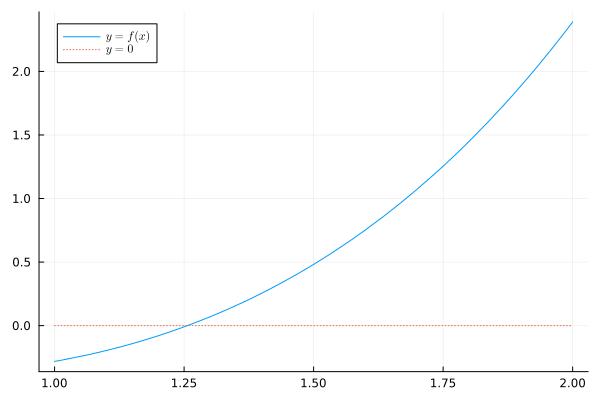

In [17]:
f = x -> exp(x) - 2*x - 1;
@show ( f(1), f(2) )

plot( f, 1, 2; label = L"y = f(x)" )
plot!( x->0; label = L"y = 0", linestyle=:dot )

::: {#def-fixed-point}

We say $\xi$ is a **fixed point** of $g: [a,b] \to \mathbb R$ if $g(\xi) = \xi$. 

:::

* We can rewrite $f(\xi) = 0$ as a fixed point problem $g(\xi) = \xi$ (for example, we could define $g(x) := x \pm f(x)$).

The change of sign theorem can be applied here:

::: {#thm-Brouwer}
# Brouwer's fixed point theorem 

Suppose $g : [a,b]\to\mathbb R$ is continuous with $g(x) \in [a,b]$ for all $x \in [a,b]$. Then, there exists $\xi\in [a,b]$ with $g(\xi) = \xi$. 

::: 

*Proof.* We can apply the change of sign theorem to $f(x) := g(x) - x$. Indeed, because $g(a), g(b) \in [a,b]$, we have $f(a) = g(a) - a \geq 0$ and $f(b) = g(b) - b \leq 0$ and thus $f$ is continuous with $f(a) f(b) \leq 0$. All roots $\xi\in[a,b]$ of $f$ are fixed points of $g$.

::: {#exr-change-sign-2}


[](../exercises/bank.html#bank-exr-change-sign-2)

Let's return to @exr-change-sign-1. You showed that $f(x) = e^x - 2x - 1$ has a root $\xi \in [1,2]$. 

Show that $f(x) = 0$ can be solved by instead considering the fixed point problems $g(x) = x$ or $h(x) = x$ where

$$
\begin{align}
    g(x) &= \log( 2x + 1 ), \\
    h(x) &= \frac{e^x - 1}{2}.
\end{align}
$$ {#eq-L3-g-h}

Show that Brouwer's fixed point theorem applies to $g$ but **not** $h$ on $[1,2]$.

::: {.exercise-solution style="display: none;"}

For $x \in [1,2]$ we have $2x + 1 > 0$, and $\log$ is one-to-one, so

\begin{align}
    g(x) = x &\iff \log(2x+1) = x \nonumber\\
             &\iff 2x + 1 = e^x \nonumber\\
             &\iff f(x) = 0, \nonumber
\end{align}

and 

\begin{align}
    h(x) = x &\iff \frac{e^x - 1}{2} = x \nonumber\\
             &\iff e^x - 2x - 1 = 0 \nonumber\\
             &\iff f(x) = 0. \nonumber
\end{align}

That is, the roots of $f$ are exactly the fixed points of $g$ and of $h$.

**$g$:** $g$ is continuous and increasing on $[1,2]$, with $g(1) = \log 3 \approx 1.10$ and $g(2) = \log 5 \approx 1.61$. So, for all $x \in [1,2]$,

\begin{align}
    1 < g(1) \leq g(x) \leq g(2) < 2. \nonumber
\end{align}

Therefore $g : [1,2] \to [1,2]$ and Brouwer's fixed point theorem gives a fixed point $\xi = g(\xi) \in [1,2]$.

**$h$:** $h(1) = \frac{e - 1}{2} \approx 0.86 < 1$ (and $h(2) = \frac{e^2 - 1}{2} \approx 3.19 > 2$), so $h$ does **not** map $[1,2]$ into $[1,2]$ and Brouwer's fixed point theorem does not apply. (Of course, $h$ still has the fixed point $\xi \in [1,2]$ found above: the theorem just cannot be used to show it.)

:::

:::

(g(1), g(2)) = (1.0986122886681098, 1.6094379124341003)
(h(1), h(2)) = (0.8591409142295225, 3.194528049465325)


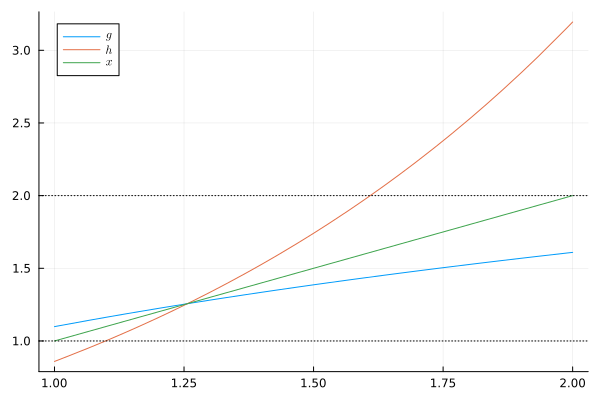

In [18]:
g = x -> log( 2*x + 1 );    
h = x -> (exp(x) - 1)/2;
id = x -> x;

@show (g(1), g(2));
@show (h(1), h(2));

plot( [g, h, id], 1, 2, label=[L"g" L"h" L"x"])
hline!(  [1, 2]; linestyle=:dot, color=:black, primary=false )

:::{.callout-tip}
# TO-DO

* Assignment 1: Due today!
* Exercises throughout the notes,
* Extra research: Research a time when real world problems have occurred when floating point numbers have not been implemented properly (add to the discussion on canvas)
* Extra reading: [myths of polynomial interpolation](https://people.maths.ox.ac.uk/trefethen/mythspaper.pdf)
* (Sign-up to office hours if you like)

:::

## Extra exercises

::: {#exr-LambertW title="Lambert W function"}

[](../exercises/bank.html#bank-exr-LambertW)

*Assignment 1, Fall 2025, [30 pts].* Prove that, for $x \geq 0$, there exists a unique $W(x) \geq 0$ for which $W(x) e^{W(x)} = x$. Show that $\Omega := W(1)$ satisfies $0.56 < \Omega < 0.58$.
   
::: {.exercise-hint style="display: none;"}

Intermediate value theorem is useful!

:::

::: {.exercise-solution style="display: none;"}

The function $F(w) := w e^w$ is continuous on $[0, \infty)$ with $F(0) = 0$ and $F(w) \to \infty$ as $w \to \infty$. Therefore, for $x \geq 0$, there exists $w_x \geq 0$ with $F(0) \leq x \leq F(w_x)$ and, by the intermediate value theorem, there exists $W \in [0, w_x]$ with $F(W) = x$. Moreover, $F'(w) = (1 + w) e^w > 0$, so $F$ is strictly increasing on $[0,\infty)$: if $W' < W < W''$ then $F(W') < x < F(W'')$. Hence $W(x) := W$ is the unique solution in $[0,\infty)$ of $W e^W = x$.

Finally, $F(0.56) = 0.56\, e^{0.56} \approx 0.980 < 1$ and $F(0.58) = 0.58\, e^{0.58} \approx 1.035 > 1$, and so (again since $F$ is continuous and strictly increasing) $\Omega = W(1) \in (0.56, 0.58)$. In the plot below, $\Omega$ is where the curve $y = w e^w$ crosses the line $y = 1$:

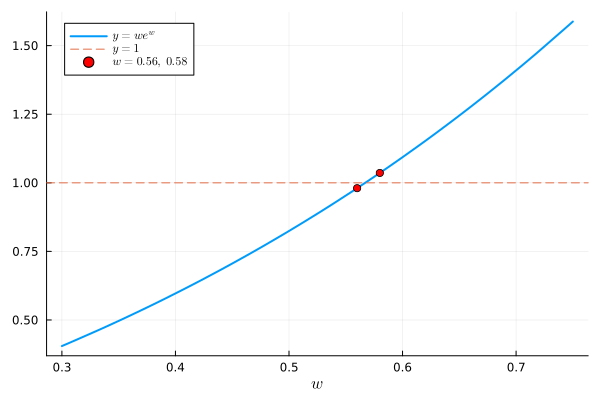

In [ ]:
using Plots, LaTeXStrings
F = w -> w * exp(w)

plot( F, 0.3, 0.75; label = L"y = w e^w", xlabel = L"w", lw = 2, legend = :topleft )
hline!( [1]; label = L"y = 1", linestyle = :dash )
scatter!( [0.56, 0.58], F.([0.56, 0.58]); label = L"w = 0.56,\ 0.58", color = :red )

:::

:::

::: {#exr-condition-numbers}

[](../exercises/bank.html#bank-exr-condition-numbers)

*Assignment 2, Fall 2025, [10 pts].*  For fixed $f$, define

\begin{align}
    g(x) &= f(x - a), \\ 
    h(x) &= b f(x), \\ 
    j(x) &= f(c x), 
\end{align}

1. What is $\kappa_g(x)$?
2. Write $\kappa_{h}(x)$ in terms of $\kappa_f$,
3. Write $\kappa_{j}(x)$ in terms of $\kappa_f$,
4. What is $\kappa_f(x)$ when $f(x) = e^{-x^2}$?
   

::: {.exercise-solution style="display: none;"}

Recall that $\kappa_f(x) = \left| \frac{x f'(x)}{f(x)} \right|$.

1. $g'(x) = f'(x - a)$ and so 
   $\kappa_g(x) = \left| \frac{x f'(x-a)}{f(x-a)} \right| = \left| \frac{x}{x - a} \right| \kappa_f(x - a)$.
2. $h'(x) = b f'(x)$ and so $\kappa_h(x) = \left| \frac{x\, b f'(x)}{b f(x)} \right| = \kappa_f(x)$ (for $b \not= 0$): scaling the output doesn't change the conditioning.
3. $j'(x) = c f'(cx)$ and so $\kappa_j(x) = \left| \frac{x\, c f'(cx)}{f(cx)} \right| = \kappa_f(cx)$. (Common mistakes: $|c| \kappa_f(cx)$, $\frac{1}{|c|}\kappa_f(x)$, or $\frac{1}{|c|}\kappa_f(cx)$.)
4. $f'(x) = -2x e^{-x^2}$ and so $\kappa_f(x) = \left| \frac{x \cdot (-2x) e^{-x^2}}{e^{-x^2}} \right| = 2x^2$.

:::

:::

::: {#exr-conditioning-diff}

[](../exercises/bank.html#bank-exr-conditioning-diff)

*Assignment 2, Fall 2025, [25 pts].* Consider the differential equation (initial value problem)

$$
\begin{align}
\begin{split}
    u'(x) &= u(x) +e^{-x} \nonumber \\
    u(0) &= -\frac12 .
\end{split}
\end{align}
$$ {#eq-exr-diff}

1. Show that $u(x) = -\frac12 e^{-x}$ solves @eq-exr-diff. 

Now we perturb the initial data, by considering 

$$
\begin{align}
\begin{split}
    u'(x) &= u(x) +e^{-x} \nonumber \\
    u(0) &= \alpha
\end{split}
\end{align}
$$ {#eq-exr-diff-2}

for $\alpha := \epsilon - \frac12$.  

2. Show that $u_{\alpha}(x) = (\alpha + \frac12) e^x -\frac12 e^{-x}$ solves @eq-exr-diff-2.
3. Plot the functions $u$ and $u_{\alpha}$ and comment on the difference between the solutions for large $x$.
4. Let $f( \alpha ) = u_\alpha( 100 )$. What is the condition number $\kappa_f( \alpha )$? 
5. Explain what happens for $\alpha \approx -\frac12$. Link your observations to your answer for question 3.

::: {.exercise-solution style="display: none;"}

1. $u'(x) = \frac12 e^{-x} = -\frac12 e^{-x} + e^{-x} = u(x) + e^{-x}$ and $u(0) = -\frac12$.
2. $u_\alpha'(x) = (\alpha + \frac12) e^x + \frac12 e^{-x} = u_\alpha(x) + e^{-x}$ and $u_\alpha(0) = (\alpha + \frac12) - \frac12 = \alpha$.

3. The difference between the two solutions is $u_\alpha(x) - u(x) = (\alpha + \frac12) e^{x} = \epsilon e^x$. Here are $u$ and $u_\alpha$ for $\epsilon = 10^{-10}$:

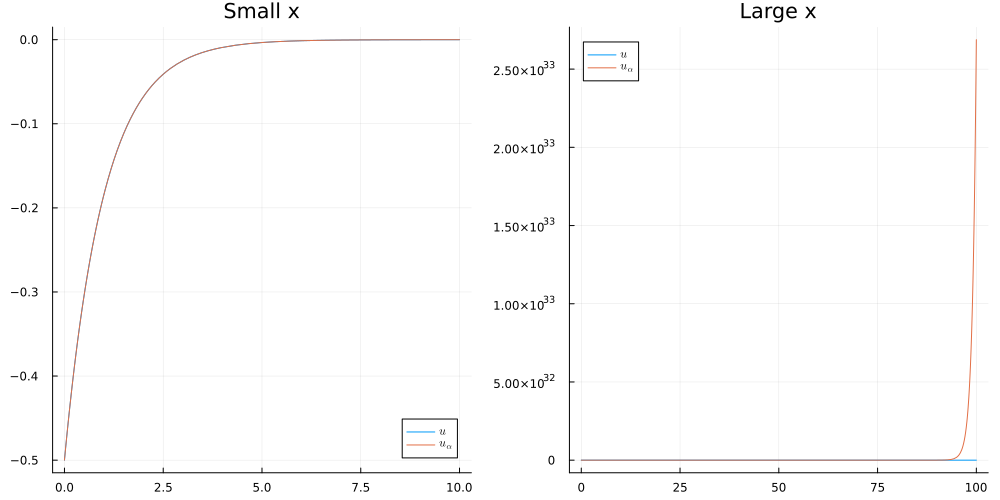

In [ ]:
α = 1e-10 - 1/2;

u = x -> -exp(-x)/2;
uα = x -> (α + 1/2)*exp(x) + u(x);

plt1 = plot([u, uα], 0, 10, label=[L"u" L"u_\alpha"], title="Small x")
plt2 = plot([u, uα], 0, 100, label=[L"u" L"u_\alpha"], title="Large x")

plot( plt1, plt2, size=(1000,500))

For small $x$ (left) the two solutions are indistinguishable: $u_\alpha(x) \approx u(x)$. For large $x$ (right) they are completely different: $u(x) = -\frac12 e^{-x}$ decays to $0$, whereas $u_\alpha(x) \approx \epsilon e^x$ grows exponentially. For example, $u(20) \approx -10^{-9}$ but $u_\alpha(20) \approx 0.05$, and $u(30) \approx -5 \times 10^{-14}$ but $u_\alpha(30) \approx 1069$.

The difference is easiest to see on a logarithmic scale:

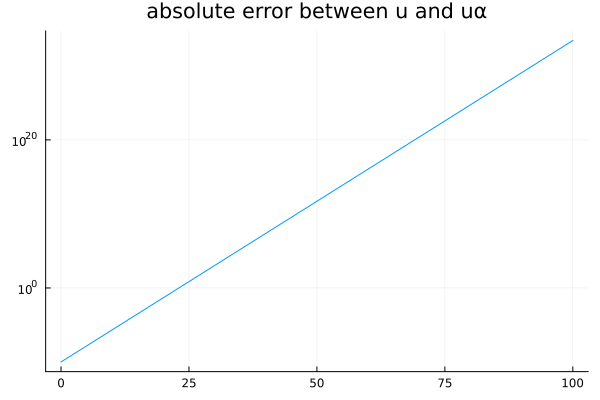

In [ ]:
err = x -> abs( u(x) - uα(x) ) 

plot( err, 0, 100 , yaxis=:log, legend = false, title="absolute error between u and uα" )

On a logarithmic $y$-axis, the error $|u(x) - u_\alpha(x)| = \epsilon e^x$ is a straight line with slope $1$ (in natural-log units): a perturbation of size $\epsilon = 10^{-10}$ in the initial condition grows by a factor $e$ for every unit increase in $x$, and is about $3 \times 10^{33}$ at $x = 100$.

4. $f(\alpha) = u_\alpha(100) = (\alpha + \frac12) e^{100} - \frac12 e^{-100}$ and $f'(\alpha) = e^{100}$, so
   \begin{align}
       \kappa_f(\alpha) = \left| \frac{\alpha f'(\alpha)}{f(\alpha)} \right| = \left| \frac{\alpha e^{100}}{(\alpha + \frac12) e^{100} - \frac12 e^{-100}} \right|. \nonumber
   \end{align}
5. As $\alpha \to -\frac12$, $\kappa_f(\alpha) \to \left| \frac{-\frac12 e^{100}}{-\frac12 e^{-100}} \right| = e^{200} \approx 7 \times 10^{86}$: the problem is extremely ill-conditioned. A tiny relative change in the initial condition (e.g. storing $-\frac12 + \epsilon$ in floating point) leads to a huge relative change in $u(100)$, which is exactly what the plots in part 3 show. 

    For example, with $\epsilon = 10^{-10}$ as in the plots: the relative change in the input is $\left|\frac{\epsilon}{-1/2}\right| = 2 \times 10^{-10}$, while $u(100) \approx -1.9 \times 10^{-44}$ and $u_\alpha(100) \approx 2.7 \times 10^{33}$, a relative change of about $1.4 \times 10^{77}$ in the output. Their ratio is $\approx 7.2 \times 10^{86} \approx e^{200} \approx \kappa_f(\alpha)$, as predicted.

:::

:::

::: {#exr-cond-number-poly}

[](../exercises/bank.html#bank-exr-cond-number-poly)

*Assignment 2, Fall 2025, [10 pts].* Let $p_{\alpha}(x) = \alpha x^n + \sum_{j=0}^{n-1} a_{j} x^j$ be a polynomial of degree $n$ and let $r(\alpha)$ be a root of $p_{\alpha}$. What is the condition number $\kappa_r(\alpha)$? 

::: {.exercise-solution style="display: none;"}

Since $p_\alpha(r(\alpha)) = 0$ for all $\alpha$, differentiating with respect to $\alpha$ gives

\begin{align}
    r(\alpha)^n + p_\alpha'\big(r(\alpha)\big)\, r'(\alpha) = 0
    \qquad \text{and so} \qquad 
    r'(\alpha) = - \frac{r(\alpha)^n}{p_\alpha'\big(r(\alpha)\big)} \nonumber
\end{align}

(assuming $r(\alpha)$ is a simple root, so that $p_\alpha'(r(\alpha)) \not= 0$). Therefore,

\begin{align}
    \kappa_r(\alpha) = \left| \frac{\alpha\, r'(\alpha)}{r(\alpha)} \right|
    = \left| \frac{\alpha\, r(\alpha)^{n-1}}{p_\alpha'\big(r(\alpha)\big)} \right|. \nonumber
\end{align}

In particular, the root is ill-conditioned when $p_\alpha'(r(\alpha))$ is small, i.e. when $r(\alpha)$ is close to a repeated root.

:::

:::